This notebook focuses on trying to find a way to segment cells within organoids properly.
The end goal is to segment cells and extract morphology features from CellProfiler.
These masks must be imported into CellProfiler to extract features.

## import libraries 

In [1]:
import argparse
import os
import pathlib
import sys
from typing import Union

import matplotlib.pyplot as plt

# Import dependencies
import numpy as np
import scipy
import skimage
import tifffile
from image_analysis_2D.file_utils.arg_parsing_utils import (
    check_for_missing_args,
    parse_args,
)
from image_analysis_2D.file_utils.notebook_init_utils import (
    bandicoot_check,
    init_notebook,
)
from image_analysis_2D.file_utils.profiling_utils import (
    start_resource_profiling,
    stop_resource_profiling,
)
from image_analysis_2D.segmentation_utils.segmentation_processing import (
    fill_holes_in_mask,
    remove_small_objects_preserve_labels,
)
from skimage import io, segmentation

root_dir, in_notebook = init_notebook()
image_base_dir = bandicoot_check(
    pathlib.Path(os.path.expanduser("~/mnt/bandicoot")).resolve(), root_dir
)

In [2]:
start_time, start_mem = start_resource_profiling()

## parse args and set paths

If a notebook run the hardcoded paths.
However, if this is run as a script, the paths are set by the parsed arguments.

In [3]:
if not in_notebook:
    args_dict = parse_args()
    patient = args_dict["patient"]
    well_fov = args_dict["well_fov"]
    clip_limit = args_dict["clip_limit"]
    twoD_method = args_dict["twoD_method"]
    check_for_missing_args(
        patient=patient,
        well_fov=well_fov,
        clip_limit=clip_limit,
        twoD_method=twoD_method,
    )
else:
    print("Running in a notebook")
    patient = "NF0014_T1"
    well_fov = "C4-2"
    clip_limit = 0.04
    twoD_method = "zmax"


if twoD_method == "zmax":
    input_dir = pathlib.Path(
        f"{image_base_dir}/data/{patient}/2D_analysis/0a.zmax_proj/{well_fov}"
    ).resolve(strict=True)
elif twoD_method == "middle":
    input_dir = pathlib.Path(
        f"{image_base_dir}/data/{patient}/2D_analysis/0b.middle_slice/{well_fov}"
    ).resolve(strict=True)
elif twoD_method == "middle_n":
    input_dir = pathlib.Path(
        f"{image_base_dir}/data/{patient}/2D_analysis/0c.middle_n_slice_max_proj/{well_fov}"
    ).resolve(strict=True)
else:
    raise ValueError(f"Unknown twoD_method: {twoD_method}")


cell_mask_path = input_dir / f"{well_fov}_cell_mask.tiff"

Running in a notebook


## Set up images, paths and functions

In [4]:
connectivity = 1
compactness = 1
image_extensions = {".tif", ".tiff"}
files = sorted(input_dir.glob("*"))
files = [str(x) for x in files if x.suffix in image_extensions]
# get the nuclei image
for f in files:
    if "555" in f:
        cell = io.imread(f)
    elif "nuclei_mask" in f:
        nuclei_mask_path = f
        nuclei_mask = io.imread(f)

/tmp/ipykernel_246183/4050469065.py:55: FutureWarning: `binary_closing` is deprecated since version 0.26 and will be removed in version 0.28. Use `skimage.morphology.closing` instead.
  inside_mask = skimage.morphology.binary_closing(
/tmp/ipykernel_246183/4050469065.py:58: FutureWarning: Parameter `min_size` is deprecated since version 0.26.0 and will be removed in 2.0.0 (or later). To avoid this warning, please use the parameter `max_size` instead. For more details, see the documentation of `remove_small_objects`. Note that the new threshold removes objects smaller than **or equal to** its value, while the previous parameter only removed smaller ones.
  inside_mask = skimage.morphology.remove_small_objects(inside_mask, min_size=5000)


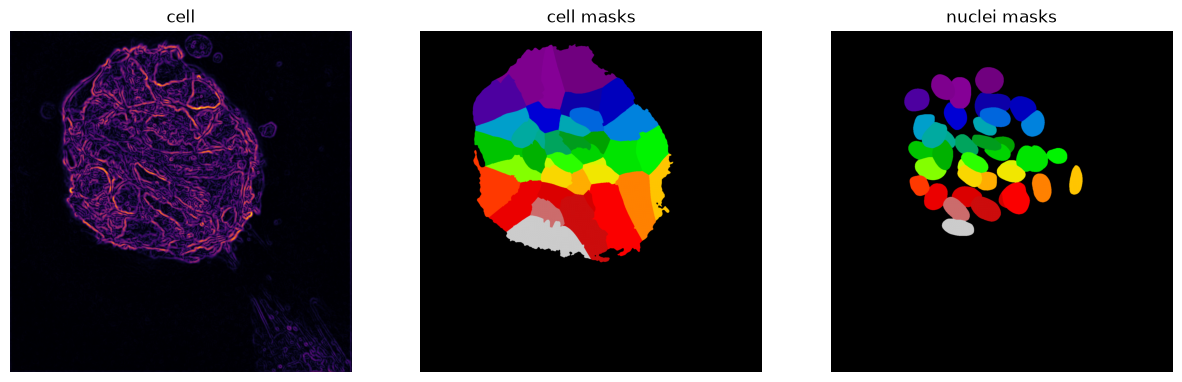

In [5]:
cell = np.array(cell)
cell = skimage.exposure.equalize_adapthist(cell, clip_limit=clip_limit)

elevation_map_threshold_signal = skimage.filters.gaussian(cell, sigma=3)
threshold = skimage.filters.threshold_otsu(elevation_map_threshold_signal)
elevation_map_threshold_signal[elevation_map_threshold_signal < threshold] = 0
elevation_map_threshold_signal[elevation_map_threshold_signal > 0] = 1
elevation_map_threshold_signal = skimage.morphology.dilation(
    elevation_map_threshold_signal,
    skimage.morphology.disk(1),
)

cell = skimage.filters.butterworth(
    cell,
    cutoff_frequency_ratio=0.08,
    order=2,
    high_pass=False,
    squared_butterworth=False,
)


cell = skimage.filters.gaussian(cell, sigma=3)
cell = skimage.filters.sobel(cell, mask=cell > 0)
cell_mask = skimage.segmentation.watershed(
    image=cell,
    markers=nuclei_mask,
    # connectivity parameter controls how pixels are connected in the watershed algorithm.
    # A value of 1 means that only directly adjacent pixels (6-connectivity in 3D) are considered connected,
    # which is appropriate for cell segmentation to prevent over-segmentation.
    connectivity=connectivity,  # keep at 1
    # compactness parameter controls the shape of the watershed regions.
    # A value of 0 means that the watershed will not enforce compactness,
    # allowing for more irregularly shaped segments,
    # which is often desirable in cell segmentation to capture the true morphology of cells.
    compactness=compactness,
    mask=elevation_map_threshold_signal,
)

# change the largest label (by area) to 0
# cleans up the output and sets the background properly
unique, counts = np.unique(cell_mask, return_counts=True)
largest_label = unique[np.argmax(counts)]
cell_mask[cell_mask == largest_label] = 0
# make sure the background is labeled as 0
# set the largest label to 0 (background)
largest_label = np.bincount(cell_mask.ravel()).argmax()
cell_mask[cell_mask == largest_label] = 0

cell_mask = fill_holes_in_mask(cell_mask, compartment="cell")


# Build a clean support mask (single main organoid only)
inside_mask = elevation_map_threshold_signal > 0
inside_mask = scipy.ndimage.binary_fill_holes(inside_mask)
inside_mask = skimage.morphology.binary_closing(
    inside_mask, footprint=skimage.morphology.disk(3)
)
inside_mask = skimage.morphology.remove_small_objects(inside_mask, min_size=5000)

# keep only largest connected component to avoid background speckles
cc = skimage.measure.label(inside_mask)
if cc.max() > 0:
    counts = np.bincount(cc.ravel())
    counts[0] = 0
    inside_mask = cc == np.argmax(counts)

# Fill unlabeled pixels only inside the clean support mask
gap_mask = inside_mask & (cell_mask == 0)
if np.any(gap_mask):
    _, nearest_idx = scipy.ndimage.distance_transform_edt(
        cell_mask == 0, return_indices=True
    )
    nearest_labels = cell_mask[tuple(nearest_idx)]
    cell_mask[gap_mask] = nearest_labels[gap_mask]

# hard background clamp (do this before and after cleanup)
cell_mask[~inside_mask] = 0

# remove small objects while preserving label IDs
cell_mask = remove_small_objects_preserve_labels(cell_mask, min_size=150)
nuclei_mask = remove_small_objects_preserve_labels(nuclei_mask, min_size=150)

# clamp again to prevent any stray fragments
cell_mask[~inside_mask] = 0


# remove small objects while preserving label IDs
cell_mask = remove_small_objects_preserve_labels(cell_mask, min_size=150)
nucleus_mask = remove_small_objects_preserve_labels(nuclei_mask, min_size=150)


unique_labels_across_cell_and_nuclei = set(np.unique(nuclei_mask)) - set(
    np.unique(cell_mask)
)
if len(unique_labels_across_cell_and_nuclei) > 0:
    # remove the labels that are not paired...
    cell_mask[np.isin(cell_mask, list(unique_labels_across_cell_and_nuclei))] = 0
    nuclei_mask[np.isin(nuclei_mask, list(unique_labels_across_cell_and_nuclei))] = 0


if in_notebook:
    plt.figure(figsize=(15, 5))
    plt.subplot(131)
    plt.imshow(cell, cmap="inferno")
    plt.axis("off")
    plt.title("cell")
    plt.subplot(132)
    plt.imshow(cell_mask, cmap="nipy_spectral")
    plt.axis("off")
    plt.title("cell masks")
    plt.subplot(133)
    plt.imshow(nuclei_mask, cmap="nipy_spectral")
    plt.axis("off")
    plt.title("nuclei masks")
    plt.show()


# save the labels
tifffile.imwrite(nuclei_mask_path, nuclei_mask.astype(np.uint16))
tifffile.imwrite(cell_mask_path, cell_mask.astype(np.uint16))

In [6]:
stop_resource_profiling(
    start_time=start_time,
    start_mem=start_mem,
    feature_type="Segmentation",
    well_fov=well_fov,
    patient_id=patient,
    channel="NoChannel",
    compartment="cell",
    CPU_GPU="GPU",
    output_file_dir=pathlib.Path(
        f"{input_dir.parent}/run_stats/{well_fov}_cell_segmentation.parquet"
    ),
)


        Memory and time profiling for the run:
        Patient ID: NF0014_T1
        Well and FOV: C4-2
        Feature type: Segmentation
        CPU/GPU: GPU
        Peak memory (tracemalloc): 247.99 MB
        Current memory (tracemalloc): 133.13 MB
        RSS at end: 789.23 MB
        Time elapsed:
        --- 3.83 seconds ---
        --- 0.06 minutes ---
        --- 0.00 hours ---
    


True